#### To Do:

- fix with Amelie that the names are the same of all the files: easier! 
- How to control for noise ==> curve_4 => noise after sec 6 (i think) -> how to fix it?
- link segment time with angle time !! -> fix data qtm: naming + conversion to opensim: GRF included: easier to calculate contact time

In [2]:
# load the project root into the notebook to be able to load functions from other modules
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tests":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
from Base.Opensim_analysis_code import angle_plot, analyze_folder_OS, merge_left_contacts
from Base.GRF_analysis_code import analyze_folder_segm

print(os.getcwd())

/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests


In [4]:
folder = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "files")
df_segm = analyze_folder_segm(folder)
# tryout1 = loadmat("../../files/NEW_Shoe25OpenSim.mat")
# tryout2 = loadmat("../../files/NEW_MN_Shoe25OpenSim_FULL.mat")

# #print(tryout1["ANGLES_TABLE"][0,0])
# angles2 = tryout2["ANGLES_TABLE"][0,0]
# tryout2["GRF_TABLE"][0,0][0][:,5]


In [5]:
OS = analyze_folder_OS("../../files/OpenSim")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left = {}
for key in OS:
    if key.endswith("_r"):
        continue

    angle_df = OS[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left[key] = angle_df_stance
OS_stance_left

['time', 'pelvis_tilt', 'pelvis_list', 'pelvis_rotation', 'pelvis_tx', 'pelvis_ty', 'pelvis_tz', 'hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'knee_angle_r_beta', 'ankle_angle_r', 'subtalar_angle_r', 'mtp_angle_r', 'hip_flexion_l', 'hip_adduction_l', 'hip_rotation_l', 'knee_angle_l', 'knee_angle_l_beta', 'ankle_angle_l', 'subtalar_angle_l', 'mtp_angle_l', 'lumbar_extension', 'lumbar_bending', 'lumbar_rotation', 'arm_flex_r', 'arm_add_r', 'arm_rot_r', 'elbow_flex_r', 'pro_sup_r', 'wrist_flex_r', 'wrist_dev_r', 'arm_flex_l', 'arm_add_l', 'arm_rot_l', 'elbow_flex_l', 'pro_sup_l', 'wrist_flex_l', 'wrist_dev_l']
['time', 'pelvis_tilt', 'pelvis_list', 'pelvis_rotation', 'pelvis_tx', 'pelvis_ty', 'pelvis_tz', 'hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'knee_angle_r_beta', 'ankle_angle_r', 'subtalar_angle_r', 'mtp_angle_r', 'hip_flexion_l', 'hip_adduction_l', 'hip_rotation_l', 'knee_angle_l', 'knee_angle_l_beta', 'ankle_angle_l', 'subtalar_an

{'pelvis_tilt':      participant shoe condition trial  time      value  side     IC     TO
 3             MN   45     Curve     1  0.03  12.377235  None  0.029  0.223
 4             MN   45     Curve     1  0.04  11.854617  None  0.029  0.223
 5             MN   45     Curve     1  0.05  11.388025  None  0.029  0.223
 6             MN   45     Curve     1  0.06  11.037579  None  0.029  0.223
 7             MN   45     Curve     1  0.07  11.024537  None  0.029  0.223
 ...          ...  ...       ...   ...   ...        ...   ...    ...    ...
 4343          MN   55  Straight     5  0.24   2.807599  None  0.094  0.280
 4344          MN   55  Straight     5  0.25   3.173681  None  0.094  0.280
 4345          MN   55  Straight     5  0.26   3.461483  None  0.094  0.280
 4346          MN   55  Straight     5  0.27   3.871756  None  0.094  0.280
 4347          MN   55  Straight     5  0.28   4.408137  None  0.094  0.280
 
 [1250 rows x 9 columns],
 'pelvis_list':      participant shoe conditi

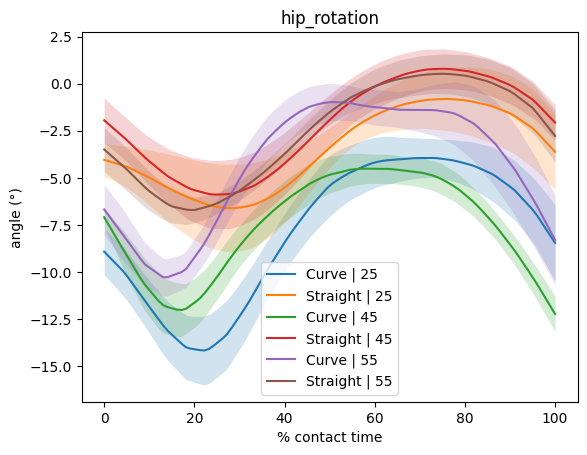

In [6]:
angle_plot(OS_stance_left, joint= "hip_rotation", comparison= ["condition", "shoe"], side="l", participant="ED")